## Model Training of Algerian Forest Fire Clean Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [216]:
df = pd.read_csv('Algerian_forest_fires_clean_dataset.csv')
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [217]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

Dropping day , month and year

In [218]:
df = df.drop(['day' ,'month' , 'year'] , axis=1)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [219]:
df.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes', 'Region'],
      dtype='object')

In [220]:
df['Classes'].unique()

array(['not fire   ', 'fire   ', 'fire', 'fire ', 'not fire', 'not fire ',
       'not fire     ', 'not fire    '], dtype=object)

In [221]:
df['Classes'] = df['Classes'].str.strip()
df['Classes'].unique()

array(['not fire', 'fire'], dtype=object)

Encoding Categories Features to integer 0 and 1

In [222]:
df['Classes'] = np.where(df['Classes']== 'not fire' , 0 , 1)

In [223]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

Now Divide Feature to Dependent and Independent Feature

In [224]:
x = df.drop('FWI' , axis=1)
y = df[['FWI']]

In [225]:
x.head(2)

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0


In [226]:
y.head(2)

,FWI
0,0.5
1,0.4


    Train test Split the Data

In [227]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train ,y_test = train_test_split(x , y , random_state=41 , test_size=0.2)

In [228]:
x_train.shape

(194, 11)

Feature Selection based on Correlation

In [229]:
x_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.644913,-0.274133,-0.328814,0.694801,0.487896,0.394802,0.610035,0.469667,0.530244,0.240515
RH,-0.644913,1.000000,0.251473,0.223055,-0.657211,-0.443526,-0.271192,-0.698599,-0.395820,-0.440789,-0.390606
Ws,-0.274133,0.251473,1.000000,0.173212,-0.165896,-0.011778,0.068692,0.000707,0.020030,-0.096048,-0.203886
Rain,-0.328814,0.223055,0.173212,1.000000,-0.528364,-0.281909,-0.295009,-0.336222,-0.294674,-0.370886,-0.043242
FFMC,0.694801,-0.657211,-0.165896,-0.528364,1.000000,0.612620,0.521440,0.739717,0.605582,0.775515,0.209985
DMC,0.487896,-0.443526,-0.011778,-0.281909,0.612620,1.000000,0.871547,0.691196,0.981976,0.596716,0.208949
DC,0.394802,-0.271192,0.068692,-0.295009,0.521440,0.871547,1.000000,0.519354,0.938506,0.530075,-0.064117
ISI,0.610035,-0.698599,0.000707,-0.336222,0.739717,0.691196,0.519354,1.000000,0.658962,0.737487,0.245674
BUI,0.469667,-0.395820,0.020030,-0.294674,0.605582,0.981976,0.938506,0.658962,1.000000,0.604907,0.106926
Classes,0.530244,-0.440789,-0.096048,-0.370886,0.775515,0.596716,0.530075,0.737487,0.604907,1.000000,0.106138


Check For MultiColinearilty

<Axes: >

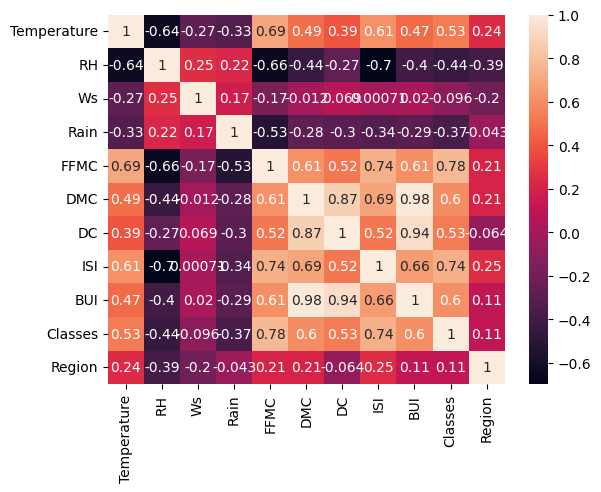

In [230]:
plt.Figure(figsize=(12 ,10))
corr = x_train.corr()
sns.heatmap(corr , annot=True)

In [231]:
def correlation(dataset , thershold):
    col_corr = set()
    corr_matrix = dataset.corr()
    # corr_matrix = 12
    # i = 0 , j = 0
    for i in range(len(corr_matrix.columns)): 
        for j in range(i):
            if abs(corr_matrix.iloc[i , j]) > thershold :
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr


In [232]:
x_train.shape

(194, 11)

In [233]:
corr_features = correlation(x_train , 0.85)

In [234]:
# Drop the features when the correlation is more than 0.85
x_train.drop(corr_features , axis=1 , inplace=True)
x_test.drop(corr_features , axis=1 , inplace=True)
x_train.shape

(194, 9)

## Feature Scaling OR Standardization

In [235]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.transform(x_test)

In [236]:
x_train_scaled

array([[ 0.24267806,  0.20086353, -0.17890605, ..., -0.46985311,
         0.89235436, -0.97958969],
       [-0.29846612,  0.13470475,  0.86232716, ...,  0.42671906,
         0.89235436, -0.97958969],
       [ 1.05439433, -0.92383583, -0.87306152, ...,  0.88649966,
         0.89235436, -0.97958969],
       ...,
       [-0.02789403,  0.3331811 , -0.52598379, ..., -0.88365565,
        -1.12063105,  1.02083557],
       [ 1.05439433, -1.18847098, -0.87306152, ...,  0.79454354,
         0.89235436,  1.02083557],
       [ 2.13668269, -2.0485352 , -0.17890605, ...,  2.70263303,
         0.89235436,  1.02083557]], shape=(194, 9))

## Box plots to understand the effect of Standard Scalar

Text(0.5, 1.0, 'X_train After Scaling')

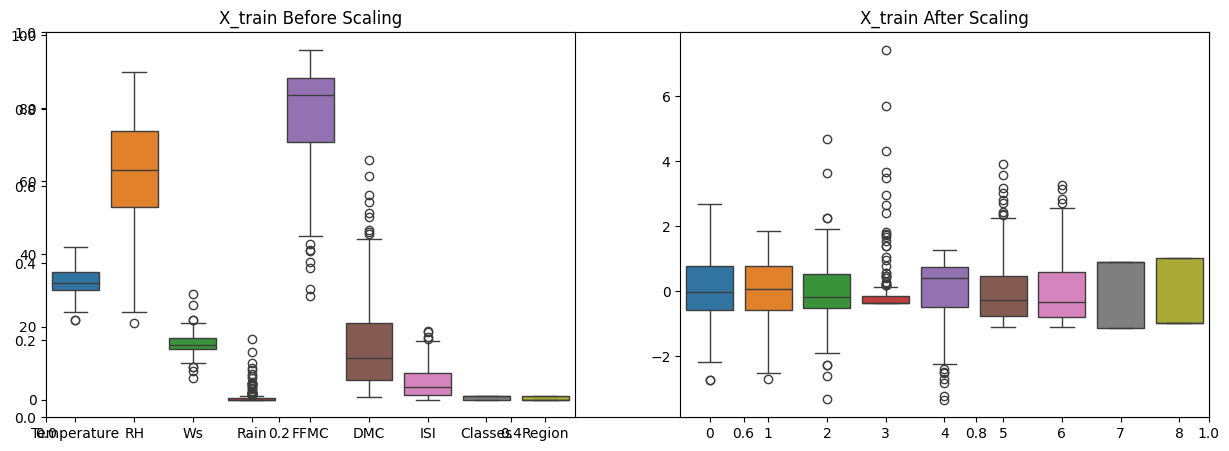

In [237]:
plt.subplots(figsize=(15 ,5))
plt.subplot(1 , 2, 1)
sns.boxplot(data=x_train)
plt.title("X_train Before Scaling")

plt.subplot(1 , 2, 2)
sns.boxplot(data=x_train_scaled)
plt.title("X_train After Scaling")

# Linear Regression Model

Mean Absolute Error  0.5481375331047672
R2 Score  0.9750011087234728


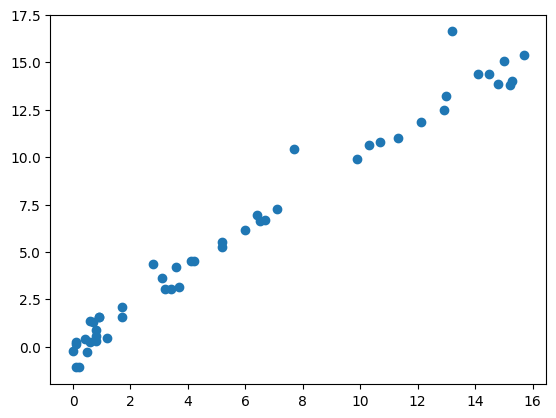

In [238]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lr = LinearRegression()
lr.fit(x_train_scaled , y_train)
y_pred = lr.predict(x_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
score = r2_score(y_test , y_pred)
print("Mean Absolute Error " , mae)
print("R2 Score " , score)
plt.scatter(y_test , y_pred)

# Cross Validation Lasso

In [239]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(x_train_scaled , y_train)
lassocv.predict(x_test_scaled)

c:\Users\LENOVO\Road_to_ml\sklearn-env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([ 3.53580897, 13.9277186 ,  6.92715986, 15.03878387, -0.97688171,
        3.50406065,  0.76029014, 15.34839442,  1.82667785, 14.43200681,
        4.52343759, 11.11812705,  3.09526947,  6.73220466, 12.36917187,
        4.59305101, -1.16838852, 11.87768793,  0.53549276,  6.83883473,
        6.03759292, 13.9023867 ,  4.19735922, 13.84150546, -0.04258987,
        1.0927804 ,  0.24674191, 16.52789382, 10.69726103,  0.46855743,
        0.93798969, 13.23587205,  1.79935362,  5.40558282,  1.37935609,
        9.95695633, 14.36355541,  2.13412475,  4.65620008,  1.57645032,
        0.08392255,  3.37522619, 10.58250128, -0.60648565,  7.34048239,
        5.22921947,  1.24578133, -0.34284083, 10.35361261])

In [240]:
lassocv.alphas_

array([7.22376612, 6.73690846, 6.28286338, 5.85941942, 5.46451416,
       5.09622419, 4.75275574, 4.43243591, 4.13370456, 3.85510671,
       3.59528542, 3.35297522, 3.12699591, 2.91624685, 2.71970157,
       2.53640279, 2.36545773, 2.2060338 , 2.0573545 , 1.91869569,
       1.78938203, 1.66878367, 1.55631323, 1.45142293, 1.35360188,
       1.26237365, 1.17729389, 1.09794822, 1.02395018, 0.95493937,
       0.89057965, 0.83055756, 0.77458076, 0.72237661, 0.67369085,
       0.62828634, 0.58594194, 0.54645142, 0.50962242, 0.47527557,
       0.44324359, 0.41337046, 0.38551067, 0.35952854, 0.33529752,
       0.31269959, 0.29162469, 0.27197016, 0.25364028, 0.23654577,
       0.22060338, 0.20573545, 0.19186957, 0.1789382 , 0.16687837,
       0.15563132, 0.14514229, 0.13536019, 0.12623736, 0.11772939,
       0.10979482, 0.10239502, 0.09549394, 0.08905797, 0.08305576,
       0.07745808, 0.07223766, 0.06736908, 0.06282863, 0.05859419,
       0.05464514, 0.05096224, 0.04752756, 0.04432436, 0.04133

In [247]:
lassocv.eps

0.001

In [248]:
lassocv.mse_path_

array([[47.16175323, 43.92387392, 71.73188185, 76.0332259 , 67.77665194],
       [41.445907  , 38.64044008, 65.37256193, 73.81915505, 64.12379142],
       [36.45848054, 34.02692009, 59.39357382, 66.15395717, 56.02863811],
       [32.10566934, 29.99734412, 54.11596028, 59.42541038, 48.73044831],
       [28.30584091, 26.4767606 , 49.45358271, 53.13375692, 42.33887562],
       [24.98789048, 23.39989076, 45.33117061, 46.52782896, 36.84996451],
       [22.089942  , 20.71004112, 41.68292965, 40.77153303, 32.14103944],
       [19.55812893, 18.35767935, 36.47270282, 35.75479306, 28.10659888],
       [17.34548915, 16.29971454, 31.90780902, 31.38157852, 24.65444775],
       [15.41118088, 14.49860998, 27.93413696, 27.56949202, 21.70455937],
       [13.71961618, 12.92161701, 24.47659103, 24.2456543 , 19.18863116],
       [12.23979765, 11.54034358, 21.46723644, 21.34702828, 17.04647867],
       [10.9447537 , 10.32990435, 18.8478403 , 18.81875012, 15.22631163],
       [ 9.8108984 ,  9.26865979, 16.5

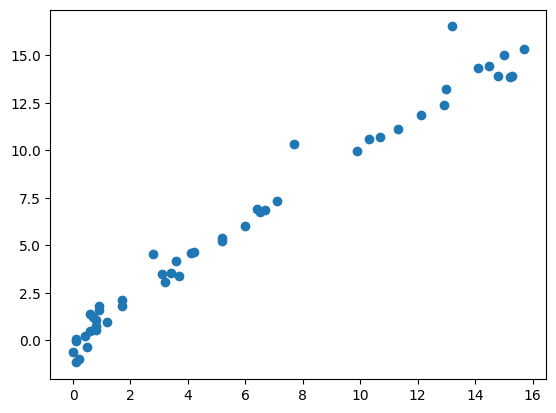

In [251]:
y_pred = lassocv.predict(x_test_scaled)
plt.scatter(y_test , y_pred)

# Lasso Regression

Mean Square Error  0.9538480840398015
R2 Score  0.955626831289851


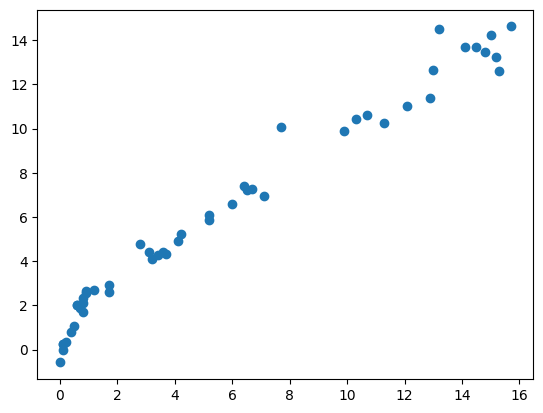

In [241]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso = Lasso()
lasso.fit(x_train_scaled , y_train)
y_pred = lasso.predict(x_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
score = r2_score(y_test , y_pred)
print("Mean Square Error " , mae)
print("R2 Score " , score)
plt.scatter(y_test , y_pred)

# Ridge Regression Model

Mean Absolute Error :  0.9538480840398015
R2 score :  0.955626831289851


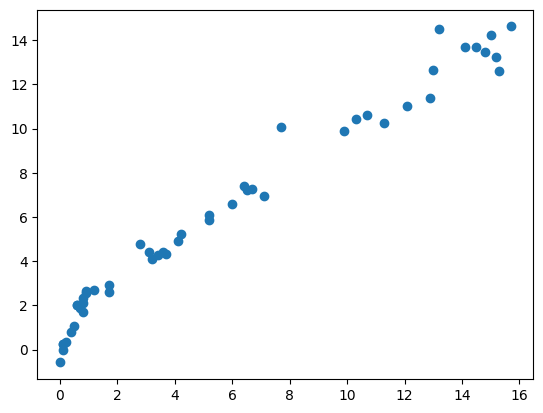

In [242]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge = Ridge()
ridge.fit(x_train_scaled , y_train)
ridge.predict(x_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
score = r2_score(y_test , y_pred)
print("Mean Absolute Error : " , mae)
print('R2 score : ' , score)
plt.scatter(y_test , y_pred)

# RidgeCV Cross Validation

In [256]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
ridgecv = RidgeCV(cv=5)
ridgecv.fit(x_train_scaled , y_train)
y_pred = ridgecv.predict(x_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
score = r2_score(y_test , y_pred)
print('Mean Absolute Error : ' , mae)
print("R2 Score : " , score)

Mean Absolute Error :  0.5629387770239136
R2 Score :  0.974370237929053


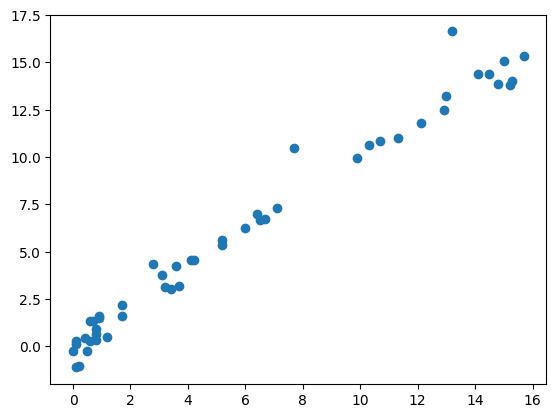

In [257]:
plt.scatter(y_test , y_pred)

In [258]:
ridgecv.alphas

(0.1, 1.0, 10.0)

In [260]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

In [261]:
ridgecv.fit_intercept

True

# ElasticNet Regression Model

Mean Absolute Error :  1.5063062559749945
R2 Score :  0.8924666651187817


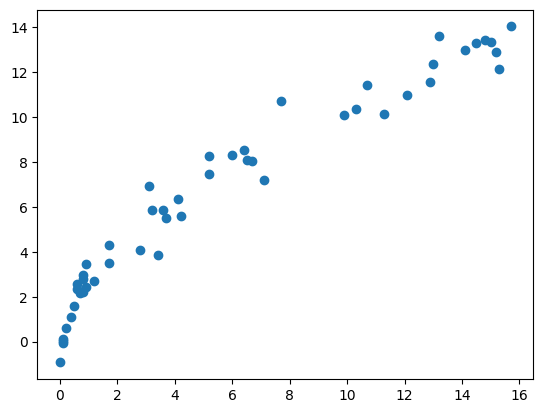

In [243]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elasticnet = ElasticNet()
elasticnet.fit(x_train_scaled , y_train)
y_pred = elasticnet.predict(x_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
score = r2_score(y_test , y_pred)
print("Mean Absolute Error : " , mae)
print("R2 Score : " , score)
plt.scatter(y_test , y_pred)

# ElasticNet Cross Validation

Mean Absolute Error :  0.6093868712935456
R2 Score :  0.9723232902561972


c:\Users\LENOVO\Road_to_ml\sklearn-env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1756: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


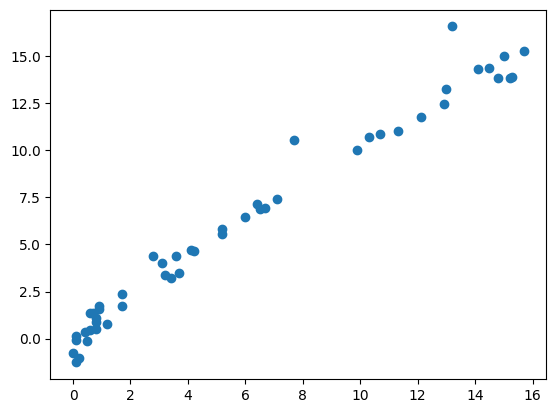

In [268]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elasticnetcv = ElasticNetCV(cv = 5)
elasticnetcv.fit(x_train_scaled , y_train)
y_pred = elasticnetcv.predict(x_test_scaled)
mae = mean_absolute_error(y_test , y_pred)
score = r2_score(y_test , y_pred)
print("Mean Absolute Error : " , mae)
print("R2 Score : " , score)
plt.scatter(y_test , y_pred)

In [269]:
elasticnetcv.alphas

'warn'

In [271]:
elasticnetcv.alpha_

np.float64(0.044120675945271165)

In [272]:
elasticnetcv.alphas_

array([14.44753225, 13.47381693, 12.56572676, 11.71883884, 10.92902832,
       10.19244839,  9.50551148,  8.86487182,  8.26740913,  7.71021342,
        7.19057084,  6.70595044,  6.25399182,  5.8324937 ,  5.43940315,
        5.07280558,  4.73091546,  4.41206759,  4.11470901,  3.83739139,
        3.57876405,  3.33756733,  3.11262647,  2.90284586,  2.70720376,
        2.52474729,  2.35458777,  2.19589644,  2.04790037,  1.90987874,
        1.7811593 ,  1.66111513,  1.54916153,  1.44475322,  1.34738169,
        1.25657268,  1.17188388,  1.09290283,  1.01924484,  0.95055115,
        0.88648718,  0.82674091,  0.77102134,  0.71905708,  0.67059504,
        0.62539918,  0.58324937,  0.54394031,  0.50728056,  0.47309155,
        0.44120676,  0.4114709 ,  0.38373914,  0.35787641,  0.33375673,
        0.31126265,  0.29028459,  0.27072038,  0.25247473,  0.23545878,
        0.21958964,  0.20479004,  0.19098787,  0.17811593,  0.16611151,
        0.15491615,  0.14447532,  0.13473817,  0.12565727,  0.11

In [273]:
elasticnetcv.coef_

array([ 0.        , -0.17756393,  0.14825868, -0.        , -0.54848731,
        3.72183854,  4.53941295,  0.4881453 , -0.36255855])

In [274]:
elasticnetcv.intercept_

np.float64(7.322680412371132)

In [275]:
elasticnetcv.l1_ratio

0.5

In [277]:
elasticnetcv.get_params()

{'alphas': 'warn',
 'copy_X': True,
 'cv': 5,
 'eps': 0.001,
 'fit_intercept': True,
 'l1_ratio': 0.5,
 'max_iter': 1000,
 'n_alphas': 'deprecated',
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': 0}